Para ciberseguridad y más en concreto para nuestro trabajo, no nos interesa redes multicapa profundas, sino redes más simples.

Vamos a estimar la mejor combinación de hiperparámetros usando el dataset entero y reduciendo las variables con PCA (compararemos los resultados).

In [2]:
import time
import numpy as np
import polars as pl
import optuna
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings

I0000 00:00:1773167247.451602 4183531 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773167247.501790 4183531 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773167251.501134 4183531 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
# ==========================================
# 1. CARGA DE DATOS
# ==========================================

path_train = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_train_NUSW_redux.csv"
path_test  = "../DATASETS/dataSets_Reducidos/nusw-nb15/datos_test_NUSW_redux.csv"

df_train = pl.read_csv(path_train)
df_test  = pl.read_csv(path_test)

TARGET_COL = "attack_cat"

# 2. Crear y_train e y_test (Normal=1, Ataque=-1)
y_train = (
    df_train.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

y_test = (
    df_test.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == "Normal")
        .then(1)
        .otherwise(-1)
        .alias("label")
    )
    .to_series()
    .cast(pl.Int8)
)

x_train = df_train.drop(TARGET_COL)
x_test  = df_test.drop(TARGET_COL)

print(f"Forma de x_train: {x_train.shape} | Clases únicas en y_train: {y_train.unique().to_list()}")
print("\nDistribución de clases en Train:")
print(y_train.value_counts())
print("\nDistribución de clases en Test:")
print(y_test.value_counts())

# Convertimos a NumPy (como RF)
X_full_train = x_train.to_numpy()
y_full_train = y_train.to_numpy()

# Split interno (no imprescindible para CV, pero lo mantenemos como lo tenías)
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_full_train, y_full_train, test_size=0.2, random_state=42, stratify=y_full_train
)

X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

print(f"Entrenamiento: {X_train_np.shape[0]} muestras")
print(f"Validación:    {X_val_np.shape[0]} muestras")
print(f"Test:          {X_test_np.shape[0]} muestras")

Forma de x_train: (175341, 12) | Clases únicas en y_train: [-1, 1]

Distribución de clases en Train:
shape: (2, 2)
┌───────┬────────┐
│ label ┆ count  │
│ ---   ┆ ---    │
│ i8    ┆ u32    │
╞═══════╪════════╡
│ -1    ┆ 119341 │
│ 1     ┆ 56000  │
└───────┴────────┘

Distribución de clases en Test:
shape: (2, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 1     ┆ 37000 │
│ -1    ┆ 45332 │
└───────┴───────┘
Entrenamiento: 140272 muestras
Validación:    35069 muestras
Test:          82332 muestras


In [4]:
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# ==========================================
# BLOQUE 0: PARCHE PARA FORZAR USO DE CPU
# ==========================================
# 🚨 Esto DEBE ir antes de importar TensorFlow
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' # Oculta la gráfica a TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suprime warnings molestos de C++

print("✅ GPU desactivada por compatibilidad. Entrenando en CPU pura.")

# ==========================================
# BLOQUE 1: PREPARACIÓN GLOBAL
# ==========================================
# 1. Forzamos la conversión a matriz plana
X_train_np = np.array(X_full_train)
y_train_np = np.array(y_full_train)

# 2. Convertimos las etiquetas -1/1 a 0/1 (Vital para ciberseguridad / Sigmoide)
y_train_01 = ((y_train_np + 1) // 2).astype(np.int8)

# 3. El escalado se hará dentro de cada fold para evitar data leakage
print("Preparando TensorFlow con escalado por fold...")

# ==========================================
# BLOQUE 2: FUNCIÓN OBJECTIVE (EL CORAZÓN)
# ==========================================
def objective(trial):
    warnings.filterwarnings("ignore")
    
    # Limpiar memoria de RAM entre cada intento
    tf.keras.backend.clear_session()
    
    # 2.1 Espacio de búsqueda de arquitectura
    n_layers = trial.suggest_int("n_layers", 1, 3)
    
    # Siempre sugerimos el número de neuronas para todas las posibles capas
    n_units_l0 = trial.suggest_int("n_units_l0", 16, 128, step=16)
    n_units_l1 = trial.suggest_int("n_units_l1", 16, 128, step=16)
    n_units_l2 = trial.suggest_int("n_units_l2", 16, 128, step=16)
    
    # 2.2 Configuración CV (2 Folds para ir rápido)
    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    f1_scores = []
    latencies = [] 

    # 2.3 Bucle de Entrenamiento y Medición
    for train_idx, val_idx in skf.split(X_train_np, y_train_01):
        X_train_cv_raw, X_val_cv_raw = X_train_np[train_idx], X_train_np[val_idx]
        y_train_cv, y_val_cv = y_train_01[train_idx], y_train_01[val_idx]

        # Escalado ajustado solo con el fold de entrenamiento
        scaler = StandardScaler()
        X_train_cv = scaler.fit_transform(X_train_cv_raw)
        X_val_cv = scaler.transform(X_val_cv_raw)

        # --- CONSTRUCCIÓN DE LA RED NEURONAL ---
        model = keras.Sequential()
        model.add(keras.layers.InputLayer(input_shape=(X_train_cv.shape[1],)))
        
        # Capa 1 (Siempre existe)
        model.add(keras.layers.Dense(n_units_l0, activation="relu"))
        # Capa 2 (Opcional)
        if n_layers >= 2:
            model.add(keras.layers.Dense(n_units_l1, activation="relu"))
        # Capa 3 (Opcional)
        if n_layers == 3:
            model.add(keras.layers.Dense(n_units_l2, activation="relu"))
            
        # Capa de salida (1 neurona, Sigmoide para probabilidad)
        model.add(keras.layers.Dense(1, activation="sigmoid"))
        
        # Compilación con Tasa de Aprendizaje por defecto de Adam (0.001)
        model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
        
        # Evita sobreentrenar y ahorra tiempo
        early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

        # Entrenar (Usa CPU obligatoriamente)
        model.fit(
            X_train_cv, y_train_cv,
            validation_data=(X_val_cv, y_val_cv),
            epochs=30,
            batch_size=2048, # Batch grande para ir rápido
            callbacks=[early_stop],
            verbose=0
        )

        # 1. Predecir y guardar Eficacia (F1)
        y_pred_prob = model.predict(X_val_cv, batch_size=4096, verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(np.int8).flatten() # Convertimos a 0/1
        f1_scores.append(f1_score(y_val_cv, y_pred, average="macro"))
        
        # 2. Medir Eficiencia (Latencia) DENTRO DEL FOLD
        subset = min(20000, len(X_val_cv))
        X_lat = X_val_cv[:subset]
        
        # Ya no necesitamos "with tf.device('/CPU:0')" porque TODO está en CPU
        # Warm-up rápido
        _ = model.predict(X_lat[:500], verbose=0)
        
        rep_lat = []
        for _ in range(5):
            t0 = time.perf_counter()
            _ = model.predict(X_lat, batch_size=len(X_lat), verbose=0)
            t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat) * 1000)
            
        latencies.append(float(np.mean(rep_lat))) # Guardamos la media de este fold

    # 2.5 El Retorno
    avg_f1 = float(np.mean(f1_scores))
    avg_lat = float(np.mean(latencies)) # Media de todos los folds
    trial.set_user_attr("f1_std", float(np.std(f1_scores)))

    return avg_f1, avg_lat

# ==========================================
# BLOQUE 3: EJECUCIÓN DEL ESTUDIO
# ==========================================
study = optuna.create_study(directions=["maximize", "minimize"], study_name="tf_mlp_ids_optimization")
print("🚀 Iniciando barrido multiobjetivo con TensorFlow (Entrenamiento y Inferencia en CPU)...")
study.optimize(objective, n_trials=25)

# ==========================================
# BLOQUE 4: EXTRACCIÓN Y PARETO
# ==========================================
pareto_ids = {t.number for t in study.best_trials}
trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "n_layers": t.params["n_layers"],
            "n_units_l0": t.params.get("n_units_l0", 0),
            "n_units_l1": t.params.get("n_units_l1", 0),
            "n_units_l2": t.params.get("n_units_l2", 0),
            "f1_macro": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t.number in pareto_ids
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("tf_mlp_trials_results_cv.csv")

print("\n✅ Resultados robustos guardados en 'tf_mlp_trials_results_cv.csv'")

[I 2026-03-10 19:29:23,036] A new study created in memory with name: tf_mlp_ids_optimization


✅ GPU desactivada por compatibilidad. Entrenando en CPU pura.
Normalizando los datos para TensorFlow...
🚀 Iniciando barrido multiobjetivo con TensorFlow (Entrenamiento y Inferencia en CPU)...


E0000 00:00:1773167363.261548 4183531 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1773167363.261612 4183531 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1773167363.261625 4183531 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1773167363.261636 4183531 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1773167363.261638 4183531 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: ai-server
I0000 00:00:1773167363.261642 4183531 cuda_diagnostics.cc:183] hostname: ai-server
I0000 00:00:1773167363.261723 4183531 cuda_diagnostics.cc:190] libcuda reported version is: 580.95.5
I0000 00:00:1773167363.261744 4183531 cuda_diagnostics.cc:194] kernel rep


✅ Resultados robustos guardados en 'tf_mlp_trials_results_cv.csv'


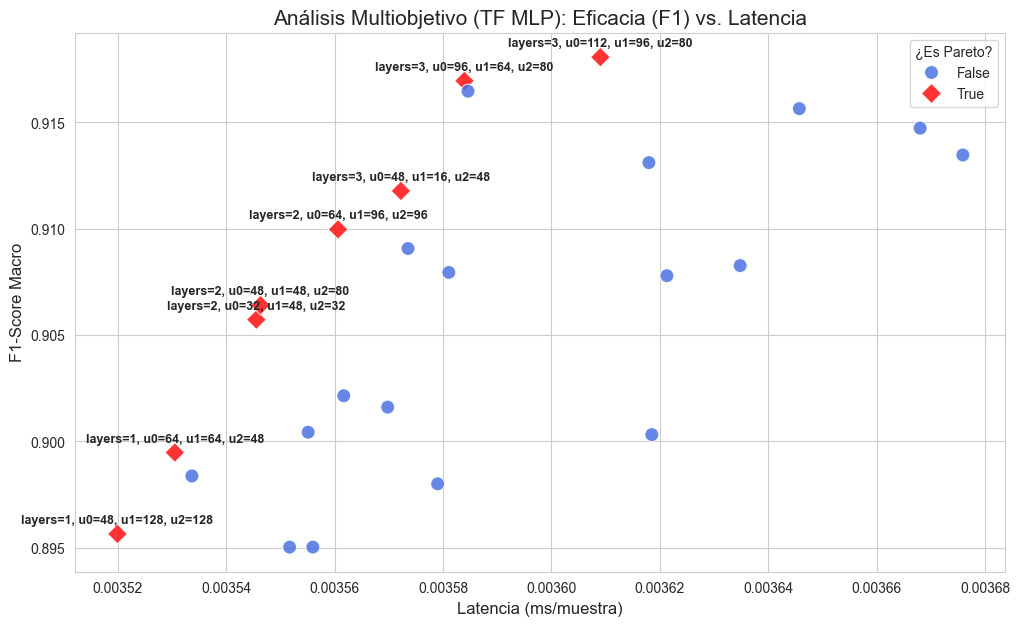

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Leer los resultados guardados del estudio del MLP TensorFlow
df = pl.read_csv("tf_mlp_trials_results_cv.csv")

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.scatterplot(
    x=df["latency_ms"].to_numpy(),
    y=df["f1_macro"].to_numpy(),
    hue=df["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"},
    s=100,
    alpha=0.8
)

pareto_points = df.filter(pl.col("is_pareto") == True)

for row in pareto_points.iter_rows(named=True):
    plt.text(
        row["latency_ms"],
        row["f1_macro"] + 0.0005,
        f"layers={int(row['n_layers'])}, u0={int(row['n_units_l0'])}, u1={int(row['n_units_l1'])}, u2={int(row['n_units_l2'])}",
        fontsize=9,
        fontweight="bold",
        ha="center"
    )

plt.title("Análisis Multiobjetivo (TF MLP): Eficacia (F1) vs. Latencia", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.legend(title="¿Es Pareto?")

plt.show()


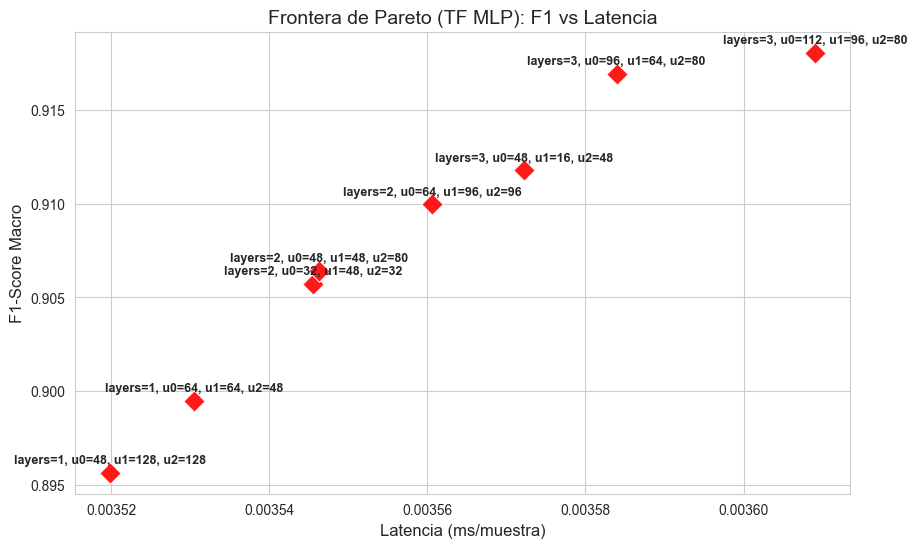

Puntos de Pareto:


n_layers,n_units_l0,n_units_l1,n_units_l2,f1_macro,f1_std,latency_ms,is_pareto
i64,i64,i64,i64,f64,f64,f64,bool
1,48,128,128,0.895645,0.001164,0.00352,true
1,64,64,48,0.899473,0.00154,0.003531,true
2,32,48,32,0.905727,0.001981,0.003546,true
2,48,48,80,0.906408,0.000569,0.003546,true
2,64,96,96,0.909971,0.004128,0.003561,true
3,48,16,48,0.911782,0.002026,0.003572,true
3,96,64,80,0.916959,0.002456,0.003584,true
3,112,96,80,0.918073,0.001601,0.003609,true


In [7]:
# SOLO REPRESENTAMOS LOS PUNTOS DE LA FRONTERA DE PARETO

pareto_df = df.filter(pl.col("is_pareto") == True).sort("latency_ms")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=pareto_df["latency_ms"].to_numpy(),
    y=pareto_df["f1_macro"].to_numpy(),
    color="red",
    marker="D",
    s=120,
    alpha=0.9
)

for row in pareto_df.iter_rows(named=True):
    plt.text(
        row["latency_ms"],
        row["f1_macro"] + 0.0005,
        f"layers={int(row['n_layers'])}, u0={int(row['n_units_l0'])}, u1={int(row['n_units_l1'])}, u2={int(row['n_units_l2'])}",
        fontsize=9,
        fontweight="bold",
        ha="center"
    )

plt.title("Frontera de Pareto (TF MLP): F1 vs Latencia", fontsize=14)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.grid(True)
plt.show()

print("Puntos de Pareto:")
display(pareto_df)

Ahora haremos lo mismo pero aplicando PCA antes, para compara los resultados

In [8]:
import os
import warnings
import time
import numpy as np
import polars as pl
import optuna
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==========================================
# BLOQUE 0: PARCHE PARA FORZAR USO DE CPU
# ==========================================
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  

import tensorflow as tf
from tensorflow import keras

print("✅ GPU desactivada por compatibilidad. Entrenando en CPU pura.")

# ==========================================
# BLOQUE 1: PREPARACIÓN GLOBAL + PCA (¡NUEVO!)
# ==========================================
X_train_np = np.array(X_full_train)
y_train_np = np.array(y_full_train)
y_train_01 = ((y_train_np + 1) // 2).astype(np.int8)

# 1. El escalado y el PCA se harán dentro de cada fold para evitar data leakage
print("Preparando TensorFlow + PCA con preprocesado por fold...")


# ==========================================
# BLOQUE 2: FUNCIÓN OBJECTIVE
# ==========================================
def objective(trial):
    warnings.filterwarnings("ignore")
    tf.keras.backend.clear_session()
    
    n_layers = trial.suggest_int("n_layers", 1, 3)
    n_units_l0 = trial.suggest_int("n_units_l0", 16, 128, step=16)
    n_units_l1 = trial.suggest_int("n_units_l1", 16, 128, step=16)
    n_units_l2 = trial.suggest_int("n_units_l2", 16, 128, step=16)
    
    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    f1_scores = []
    latencies = [] 

    # IMPORTANTE: escalamos y aplicamos PCA dentro de cada fold
    for train_idx, val_idx in skf.split(X_train_np, y_train_01):
        X_train_cv_raw, X_val_cv_raw = X_train_np[train_idx], X_train_np[val_idx]
        y_train_cv, y_val_cv = y_train_01[train_idx], y_train_01[val_idx]

        scaler = StandardScaler()
        X_train_cv_scaled = scaler.fit_transform(X_train_cv_raw)
        X_val_cv_scaled = scaler.transform(X_val_cv_raw)

        pca = PCA(n_components=0.95, random_state=42)
        X_train_cv = pca.fit_transform(X_train_cv_scaled)
        X_val_cv = pca.transform(X_val_cv_scaled)
        num_componentes = X_train_cv.shape[1]

        model = keras.Sequential()
        # La InputLayer usa dinámicamente el número de componentes calculado en este fold
        model.add(keras.layers.InputLayer(input_shape=(num_componentes,)))
        
        model.add(keras.layers.Dense(n_units_l0, activation="relu"))
        if n_layers >= 2:
            model.add(keras.layers.Dense(n_units_l1, activation="relu"))
        if n_layers == 3:
            model.add(keras.layers.Dense(n_units_l2, activation="relu"))
            
        model.add(keras.layers.Dense(1, activation="sigmoid"))
        model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
        early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

        model.fit(
            X_train_cv, y_train_cv,
            validation_data=(X_val_cv, y_val_cv),
            epochs=30,
            batch_size=2048, 
            callbacks=[early_stop],
            verbose=0
        )

        y_pred_prob = model.predict(X_val_cv, batch_size=4096, verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(np.int8).flatten() 
        f1_scores.append(f1_score(y_val_cv, y_pred, average="macro"))
        
        subset = min(20000, len(X_val_cv))
        X_lat = X_val_cv[:subset]
        
        _ = model.predict(X_lat[:500], verbose=0)
        
        rep_lat = []
        for _ in range(5):
            t0 = time.perf_counter()
            _ = model.predict(X_lat, batch_size=len(X_lat), verbose=0)
            t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat) * 1000)
            
        latencies.append(float(np.mean(rep_lat))) 

    avg_f1 = float(np.mean(f1_scores))
    avg_lat = float(np.mean(latencies)) 
    trial.set_user_attr("f1_std", float(np.std(f1_scores)))

    return avg_f1, avg_lat

# ==========================================
# BLOQUE 3: EJECUCIÓN DEL ESTUDIO
# ==========================================
study = optuna.create_study(directions=["maximize", "minimize"], study_name="tf_mlp_pca_optimization")
print(f"🚀 Iniciando barrido con TensorFlow + PCA ({num_componentes} componentes)...")
study.optimize(objective, n_trials=25)

# ==========================================
# BLOQUE 4: EXTRACCIÓN Y PARETO
# ==========================================
pareto_ids = {t.number for t in study.best_trials}
trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "n_layers": t.params["n_layers"],
            "n_units_l0": t.params.get("n_units_l0", 0),
            "n_units_l1": t.params.get("n_units_l1", 0),
            "n_units_l2": t.params.get("n_units_l2", 0),
            "f1_macro": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t.number in pareto_ids
        })

df_results = pl.DataFrame(trials_data)
# Cambiamos el nombre del archivo para no sobreescribir el anterior
df_results.write_csv("tf_mlp_pca_trials_results_cv.csv")

print("\n✅ Resultados robustos guardados en 'tf_mlp_pca_trials_results_cv.csv'")

[I 2026-03-10 20:14:54,239] A new study created in memory with name: tf_mlp_pca_optimization


✅ GPU desactivada por compatibilidad. Entrenando en CPU pura.
Normalizando los datos...
Aplicando PCA (reteniendo el 95% de la varianza)...
✅ PCA Completado: Hemos pasado de 12 variables a solo 9 componentes.
🚀 Iniciando barrido con TensorFlow + PCA (9 componentes)...


[I 2026-03-10 20:15:08,590] Trial 0 finished with values: [0.8991480079313453, 0.0035607365798205138] and parameters: {'n_layers': 1, 'n_units_l0': 80, 'n_units_l1': 32, 'n_units_l2': 16}.
[I 2026-03-10 20:15:23,251] Trial 1 finished with values: [0.8992772222186585, 0.003523451732471585] and parameters: {'n_layers': 1, 'n_units_l0': 80, 'n_units_l1': 32, 'n_units_l2': 48}.
[I 2026-03-10 20:15:37,878] Trial 2 finished with values: [0.8990259420337601, 0.003522091470658779] and parameters: {'n_layers': 1, 'n_units_l0': 96, 'n_units_l1': 128, 'n_units_l2': 112}.
[I 2026-03-10 20:15:56,068] Trial 3 finished with values: [0.9098635471398095, 0.003524349899962544] and parameters: {'n_layers': 2, 'n_units_l0': 112, 'n_units_l1': 80, 'n_units_l2': 32}.
[I 2026-03-10 20:16:10,671] Trial 4 finished with values: [0.8995664635203953, 0.0035203604307025666] and parameters: {'n_layers': 1, 'n_units_l0': 96, 'n_units_l1': 48, 'n_units_l2': 32}.
[I 2026-03-10 20:16:24,676] Trial 5 finished with value


✅ Resultados robustos guardados en 'tf_mlp_pca_trials_results_cv.csv'


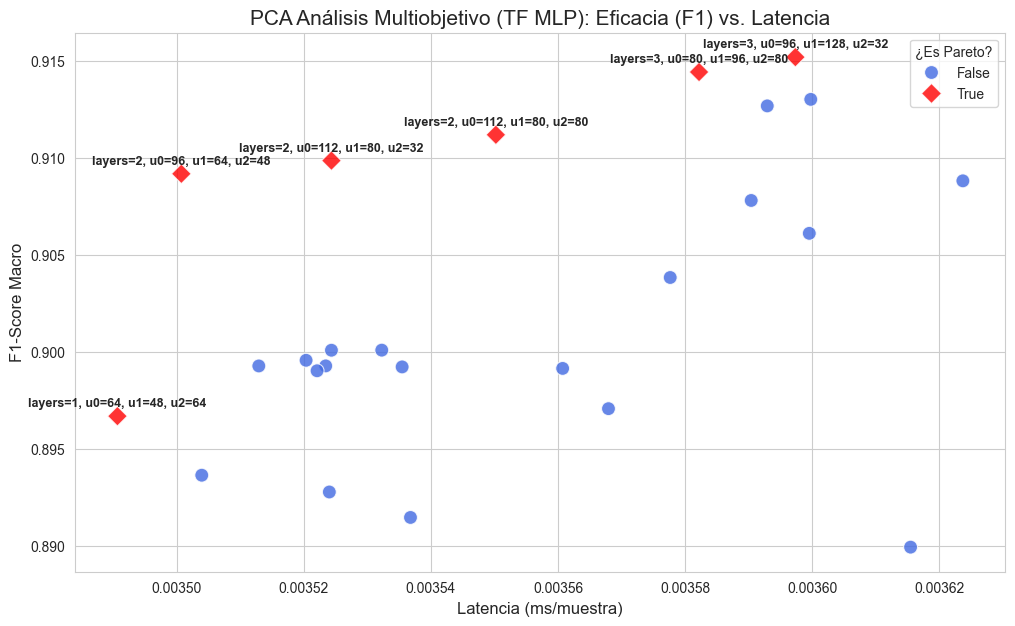

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Leer los resultados guardados del estudio del MLP TensorFlow
df = pl.read_csv("tf_mlp_pca_trials_results_cv.csv")

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.scatterplot(
    x=df["latency_ms"].to_numpy(),
    y=df["f1_macro"].to_numpy(),
    hue=df["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"},
    s=100,
    alpha=0.8
)

pareto_points = df.filter(pl.col("is_pareto") == True)

for row in pareto_points.iter_rows(named=True):
    plt.text(
        row["latency_ms"],
        row["f1_macro"] + 0.0005,
        f"layers={int(row['n_layers'])}, u0={int(row['n_units_l0'])}, u1={int(row['n_units_l1'])}, u2={int(row['n_units_l2'])}",
        fontsize=9,
        fontweight="bold",
        ha="center"
    )

plt.title("PCA Análisis Multiobjetivo (TF MLP): Eficacia (F1) vs. Latencia", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.legend(title="¿Es Pareto?")

plt.show()


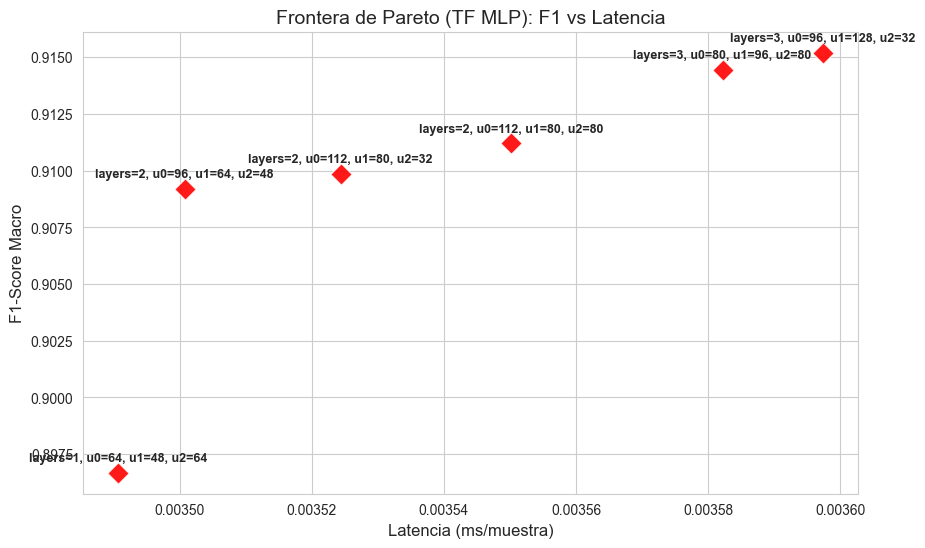

Puntos de Pareto:


n_layers,n_units_l0,n_units_l1,n_units_l2,f1_macro,f1_std,latency_ms,is_pareto
i64,i64,i64,i64,f64,f64,f64,bool
1,64,48,64,0.896687,0.000955,0.003491,true
2,96,64,48,0.909184,0.000839,0.003501,true
2,112,80,32,0.909864,0.001079,0.003524,true
2,112,80,80,0.911197,0.001119,0.00355,true
3,80,96,80,0.914433,0.001792,0.003582,true
3,96,128,32,0.915199,0.003063,0.003597,true


In [10]:
# SOLO REPRESENTAMOS LOS PUNTOS DE LA FRONTERA DE PARETO

pareto_df = df.filter(pl.col("is_pareto") == True).sort("latency_ms")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=pareto_df["latency_ms"].to_numpy(),
    y=pareto_df["f1_macro"].to_numpy(),
    color="red",
    marker="D",
    s=120,
    alpha=0.9
)

for row in pareto_df.iter_rows(named=True):
    plt.text(
        row["latency_ms"],
        row["f1_macro"] + 0.0005,
        f"layers={int(row['n_layers'])}, u0={int(row['n_units_l0'])}, u1={int(row['n_units_l1'])}, u2={int(row['n_units_l2'])}",
        fontsize=9,
        fontweight="bold",
        ha="center"
    )

plt.title("Frontera de Pareto (TF MLP): F1 vs Latencia", fontsize=14)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.grid(True)
plt.show()

print("Puntos de Pareto:")
display(pareto_df)

In [14]:
import os
import time
import numpy as np
import polars as pl
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler

# ==========================================
# BLOQUE 0: PARCHE PARA FORZAR USO DE CPU
# ==========================================
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' 
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  

import tensorflow as tf
from tensorflow import keras

# ==========================================
# EVALUACIÓN FINAL EN TEST (4 CANDIDATOS MLP)
# ==========================================

candidatos = [
    {"h": (64,),           "nombre": "MLP - 1. Lanzadera (Ligero)"},
    {"h": (64, 96),         "nombre": "MLP - 2. Equilibrado"},
    {"h": (96, 64, 80),    "nombre": "MLP - 3. Robusto"},
    {"h": (112, 96, 80),  "nombre": "MLP - 4. Estado del Arte (Pico)"},
]

resultados_finales = []

print("--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (TensorFlow MLP) ---\n")

# 1. Aseguramos que todo sea NumPy para evitar warnings
X_train_np = np.array(X_full_train)
X_test_np_arr = np.array(X_test_np)

# 2. Convertimos y_train/y_test a 0/1 para métricas binarias correctas
y_full_train01 = ((np.array(y_full_train) + 1) // 2).astype(np.int8)
y_test_np01    = ((np.array(y_test_np) + 1) // 2).astype(np.int8)

# 3. ESCALADO DE DATOS (Vital para MLP, sin Data Leakage)
print("Normalizando datos (ajustando solo en Train)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np_arr)

for c in candidatos:
    print(f"\n🚀 Probando: {c['nombre']} (Capas={len(c['h'])}, Neuronas={c['h']})...")
    
    # Limpiamos memoria RAM para que no se acumulen modelos
    tf.keras.backend.clear_session()

    # 4. Inicializamos modelo dinámico
    model = keras.Sequential()
    model.add(keras.layers.InputLayer(input_shape=(X_train_scaled.shape[1],)))
    
    for units in c["h"]:
        model.add(keras.layers.Dense(units, activation="relu"))
        
    model.add(keras.layers.Dense(1, activation="sigmoid"))
    
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    
    # 5. Entrenamiento (Separamos un 10% interno para el Early Stop)
    early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    
    model.fit(
        X_train_scaled, y_full_train01,
        validation_split=0.1, 
        epochs=40,
        batch_size=2048,
        callbacks=[early_stop],
        verbose=0
    )

    # 6. Medición en el Set de Test
    # Warm-up (despertar cachés del procesador)
    _ = model.predict(X_test_scaled[:min(1000, len(X_test_scaled))], verbose=0)

    # Cronometramos la predicción de todo el bloque
    t0 = time.perf_counter()
    y_pred_prob = model.predict(X_test_scaled, batch_size=4096, verbose=0)
    t1 = time.perf_counter()
    
    # Convertimos probabilidades a 0 o 1
    y_pred01 = (y_pred_prob > 0.5).astype(np.int8).flatten()

    # 7. Cálculo de métricas
    tiempo_total = t1 - t0
    latencia = (tiempo_total / len(y_test_np01)) * 1000 # ms por muestra
    
    f1_test = f1_score(y_test_np01, y_pred01, average="macro")
    acc_test = accuracy_score(y_test_np01, y_pred01)

    # 8. Guardado de resultados
    resultados_finales.append({
        "Perfil": c["nombre"],
        "Num_Capas": len(c["h"]),
        "Estructura": str(c["h"]),
        "F1_Test": float(f1_test),
        "Accuracy_Test": float(acc_test),
        "Latencia_ms": float(latencia)
    })

# 9. Creación de la tabla final
df_final = pl.DataFrame(resultados_finales)
print("\n" + "="*85)
print("                    TABLA COMPARATIVA FINAL (TensorFlow MLP)")
print("="*85)
print(df_final)

--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (TensorFlow MLP) ---

Normalizando datos (ajustando solo en Train)...

🚀 Probando: MLP - 1. Lanzadera (Ligero) (Capas=1, Neuronas=(64,))...

🚀 Probando: MLP - 2. Equilibrado (Capas=2, Neuronas=(64, 96))...

🚀 Probando: MLP - 3. Robusto (Capas=3, Neuronas=(96, 64, 80))...

🚀 Probando: MLP - 4. Estado del Arte (Pico) (Capas=3, Neuronas=(112, 96, 80))...

                    TABLA COMPARATIVA FINAL (TensorFlow MLP)
shape: (4, 6)
┌─────────────────────────────┬───────────┬───────────────┬──────────┬───────────────┬─────────────┐
│ Perfil                      ┆ Num_Capas ┆ Estructura    ┆ F1_Test  ┆ Accuracy_Test ┆ Latencia_ms │
│ ---                         ┆ ---       ┆ ---           ┆ ---      ┆ ---           ┆ ---         │
│ str                         ┆ i64       ┆ str           ┆ f64      ┆ f64           ┆ f64         │
╞═════════════════════════════╪═══════════╪═══════════════╪══════════╪═══════════════╪═════════════╡
│ MLP - 1. Lanzadera (L

Generando predicciones sobre X_test para las gráficas...


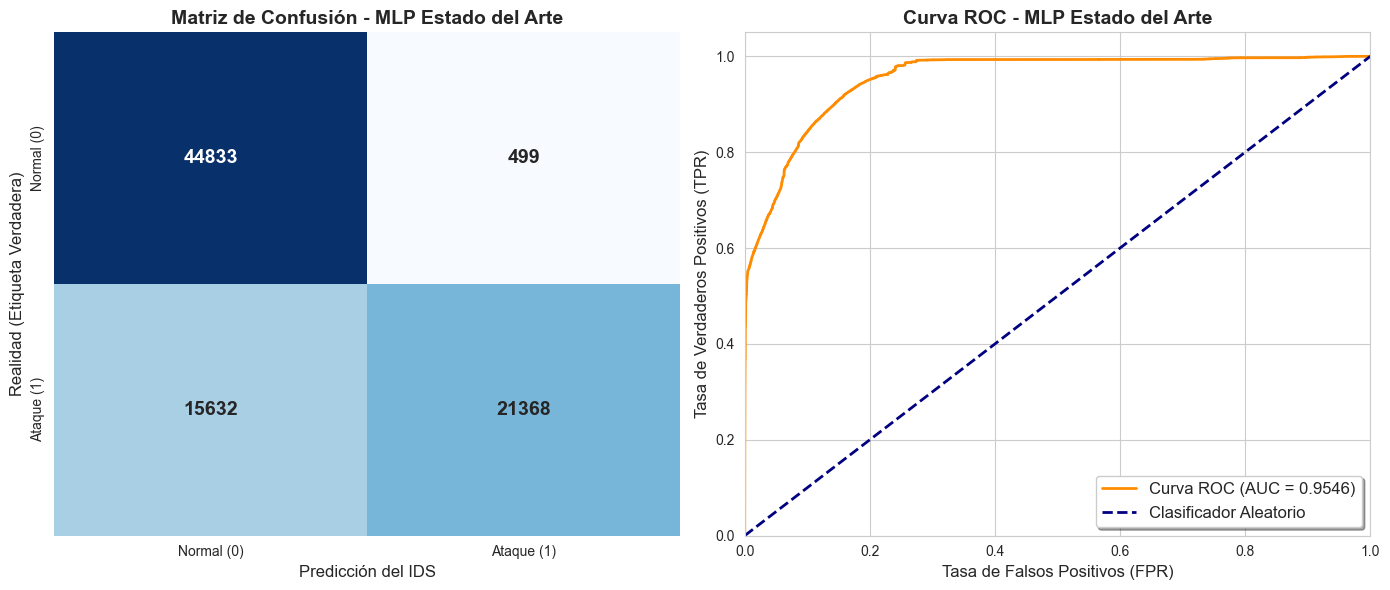

In [17]:
# Generamos la curva ROC y la matriz de confusión para el mejor modelo

import time
import os
import psutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow import keras


# 1. Limpiamos la memoria por si acaso
tf.keras.backend.clear_session()

# 2. Construimos la arquitectura exacta
model_final = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(112, activation="relu"),
    keras.layers.Dense(96, activation="relu"),
    keras.layers.Dense(80, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

# 3. Compilamos con su Learning Rate específico (0.0001)
model_final.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# 4. Entrenamos
model_final.fit(
    X_train_scaled, y_full_train01,
    validation_split=0.1, 
    epochs=40,
    batch_size=2048,
    callbacks=[early_stop],
    verbose=0
)

# ==========================================
# 5. BENCHMARK DE RECURSOS COMPUTACIONALES
# ==========================================
print("Midiendo recursos computacionales del modelo ganador (MLP)...")
proceso = psutil.Process(os.getpid())
block_size = 4096
repetitions = 3

# Warm-up fuera de la medicion
_ = model_final.predict(X_test_scaled[:min(1024, len(X_test_scaled))], batch_size=1024, verbose=0)

tiempos_muro = []
tiempos_cpu = []
picos_ram = []

for _ in range(repetitions):
    cpu_ini = proceso.cpu_times()
    ram_base = proceso.memory_info().rss / (1024 * 1024)
    pico_ram_rep = ram_base

    t0 = time.perf_counter()
    for inicio in range(0, len(X_test_scaled), block_size):
        fin = inicio + block_size
        bloque = X_test_scaled[inicio:fin]
        _ = model_final.predict(bloque, batch_size=1024, verbose=0)

        ram_actual = proceso.memory_info().rss / (1024 * 1024)
        if ram_actual > pico_ram_rep:
            pico_ram_rep = ram_actual

    t1 = time.perf_counter()
    cpu_fin = proceso.cpu_times()

    tiempos_muro.append(t1 - t0)
    tiempos_cpu.append((cpu_fin.user - cpu_ini.user) + (cpu_fin.system - cpu_ini.system))
    picos_ram.append(pico_ram_rep - ram_base)

media_muro = float(np.mean(tiempos_muro))
media_cpu = float(np.mean(tiempos_cpu))
pico_max_ram = float(np.max(picos_ram))
total_nucleos = psutil.cpu_count(logical=True)

df_benchmark_mlp = pl.DataFrame([{
    "Modelo": "MLP Estado del Arte",
    "Latencia_ms": round((media_muro / len(X_test_scaled)) * 1000, 5),
    "Thruput (paq/s)": round(len(X_test_scaled) / media_muro, 0),
    "Núcleos CPU": round(media_cpu / media_muro if media_muro > 0 else 1, 1),
    "Pico RAM (MB)": round(pico_max_ram, 2),
    "Porcentaje CPU": round(((media_cpu / media_muro) / total_nucleos) * 100 if media_muro > 0 else 0, 1)
}])

print(df_benchmark_mlp)

# ==========================================
# 6. GENERACIÓN DE GRÁFICAS (ROC y MATRIZ)
# ==========================================
print("Generando predicciones sobre X_test para las gráficas...")
y_pred_prob = model_final.predict(X_test_scaled, batch_size=4096, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(np.int8).flatten()

# Cálculos
cm = confusion_matrix(y_test_np01, y_pred)
fpr, tpr, thresholds = roc_curve(y_test_np01, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Dibujo de las gráficas
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- GRÁFICA 1: MATRIZ DE CONFUSIÓN ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Normal (0)', 'Ataque (1)'], 
            yticklabels=['Normal (0)', 'Ataque (1)'],
            annot_kws={"size": 14, "weight": "bold"},
            cbar=False)

axes[0].set_title('Matriz de Confusión - MLP Estado del Arte', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicción del IDS', fontsize=12)
axes[0].set_ylabel('Realidad (Etiqueta Verdadera)', fontsize=12)

# --- GRÁFICA 2: CURVA ROC ---
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
axes[1].set_title('Curva ROC - MLP Estado del Arte', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

El modelo Multilayer Perceptron (MLP) presenta un rendimiento sobresaliente en su capacidad de discriminación, evidenciado por un AUC de 0.9546 en la Curva ROC. Esto demuestra que la red neuronal es matemáticamente excelente al separar y ordenar el tráfico: asigna de forma sistemática probabilidades más altas a los ataques que al tráfico normal.

Sin embargo, la Matriz de Confusión original muestra una tasa elevada de Falsos Negativos. Esta aparente contradicción es un fenómeno documentado en escenarios de ciberseguridad con datos desbalanceados. Al predominar el tráfico legítimo durante el entrenamiento, el modelo se vuelve conservador en sus niveles de confianza.